# Фундаментальный анализ корпоративных облигаций

[Открыть аналитический отчёт по результатам скрининга корпоративных облигаций](https://github.com/AlexandreFyodorov/My_Research_Projects/blob/main/Issledovanie_market/Results/analys_corporat_obligat_results.ipynb)

## 1. Описание проекта

Автоматизированная система поэтапного анализа и скрининга корпоративных облигаций российского рынка. Проект объединяет данные из двух источников: детальная биржевая статистика из терминала QUIK (файл `Oblig_corporat.xlsx`) и рейтинговые оценки с информационного портала smart-lab.ru (`bonds_parsed.xlsx`). Скрипт реализует полный цикл обработки: от загрузки и объединения информации до расчёта ключевых метрик доходности, визуализации результатов и формирования рекомендаций по инвестированию.

**Цель:** комплексный анализ корпоративных облигаций на основе данных из двух источников:
 - `Oblig_corporat.xlsx` – данные из QUIK (основные параметры);
 - `bonds_parsed.xlsx` – данные с smart-lab.ru (рейтинги).

**Что делает код:**
- объединяет данные по полю "ShortName" / "Инструмент сокр.";
- рассчитывает доходность к погашению (YTM) и доходность к оферте (YTC);
- строит интерактивные графики: распределение YTM, кривая доходности, YTM vs дюрация и др.;
- формирует таблицу ключевых метрик;
- даёт рекомендацию топ-10 облигаций с наилучшим соотношением доходность/риск.

### 1.1. Цель работы

Разработать воспроизводимый алгоритм скрининга облигаций, позволяющий инвестору объективно оценивать соотношение доходности и риска, выявлять наиболее привлекательные инструменты с учётом кредитного качества эмитента, дюрации и номинала, а также формировать обоснованный портфель с фиксированной доходностью.

### 1.2. Задачи проекта

1. **Сбор и предобработка данных** — объединение информации из двух источников (QUIK и smart-lab.ru), очистка, приведение типов данных, обработка пропусков.
2. **Расчёт ключевых метрик** — вычисление доходности к погашению (YTM), доходности к оферте (YTC), текущей доходности, а также вспомогательных параметров (дюрация, срок до погашения, объём выпуска).
3. **Фильтрация по качеству** — отбор инструментов с заданными ограничениями по доходности, дюрации, кредитному рейтингу и номиналу.
4. **Визуализация результатов** — создание наглядных интерактивных графиков (гистограммы, диаграммы рассеяния, кривая доходности, корреляционная матрица, pie chart) для анализа отфильтрованной выборки.
5. **Формирование рекомендаций** — ранжирование облигаций по критерию максимизации YTM/дюрация, выделение топ‑30 бумаг с обоснованием выбора.
6. **Экспорт данных** — сохранение всех промежуточных и итоговых таблиц для дальнейшего анализа.

### 1.3. Формирование выборки

**Источники данных:**

- **Oblig_corporat.xlsx** — выгрузка из терминала QUIK, содержащая:
  - цену закрытия (в процентах от номинала);
  - размер купона (в процентах годовых);
  - накопленный купонный доход (НКД);
  - дюрацию (лет);
  - объём выпуска (руб);
  - даты погашения и оферты;
  - номинал облигации;
  - ISIN‑код и краткое наименование инструмента (`Инструмент сокр.`).

- **bonds_parsed.xlsx** — данные с портала smart-lab.ru, содержащие:
  - кредитные рейтинги эмитентов (Rating);
  - краткие наименования (`ShortName`) для сопоставления.

**Критерии включения (фильтры):**

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| **Минимальная доходность YTM** | 15.0% | Уровень выше ключевой ставки ЦБ РФ, обеспечивающий положительную премию за риск |
| **Максимальная доходность YTM** | 30.0% | Отсечение чрезмерно рискованных инструментов с потенциально высокой вероятностью дефолта |
| **Максимальная дюрация** | 3.0 года | Ограничение процентного риска; при горизонте инвестирования до 3 лет чувствительность к изменению ставок минимальна |
| **Минимальный рейтинг** | A+ | Отбор только эмитентов с высоким кредитным качеством (AAA и AA) |
| **Номинал** | 1000 руб. | Стандартный номинал для розничных инвесторов на российском рынке |

**Результат фильтрации:** 26 облигаций, соответствующих заданным критериям.

### 1.4. План работы

#### Этап 0. Настройка и загрузка данных
- Подключение необходимых библиотек: `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`, `datetime`, `warnings`, `os`.
- Определение путей к исходным файлам и параметров фильтрации.
- Загрузка `Oblig_corporat.xlsx` и `bonds_parsed.xlsx`, обработка ошибок.

#### Этап 1. Объединение данных
- Приведение названий облигаций к единому строковому формату.
- Извлечение рейтингов из `bonds_parsed.xlsx` и добавление их к основному датафрейму через `left join` по полю `ShortName` ↔ `Инструмент сокр.`.
- Сохранение исходных колонок с рейтингом (если отсутствуют, присваивается `NaN`).

#### Этап 2. Приведение типов и обработка пропусков
- Преобразование числовых колонок (`Цена закр.`, `Размер купона`, `НКД`, `Дюрация`, `Объем обр.`, `Номинал`) к типу `float`.
- Преобразование дат (`Погашение`, `Оферта`) к типу `datetime`.
- Заполнение номинала значением 1000 руб., если отсутствует.
- Расчёт дюрации как срока до погашения, если она не задана.
- Переименование колонок для удобства дальнейшей работы (например, `price_percent`, `coupon_percent`, `duration_years`).

#### Этап 3. Расчёт ключевых метрик
- **Текущая доходность:** `current_yield = coupon_percent / price_percent * 100`.
- **Доходность к погашению (YTM):** приближённая формула:

<div class="alert alert-info">
</div>

In [98]:
# !pip install numpy_financial

In [92]:
# 1. Импорт библиотек и настройки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
import os

# Подавляем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Настройки стилей для статических графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# 2. Настройки путей и параметров фильтрации

# Пути к файлам
OUTPUT_DIR = r"C:\Users\1\Documents\TRADE_2026\Obligatsii"
PARSED_FILE = os.path.join(OUTPUT_DIR, "bonds_parsed.xlsx")
LOCAL_FILE = os.path.join(OUTPUT_DIR, "Oblig_corporat.xlsx")

# Параметры фильтрации (можно изменять)
FILTERS = {
    'min_ytm': 15.0,           # минимальная доходность, %
    'max_ytm': 30.0,           # максимальная доходность, %
    'max_duration': 3.0,       # максимальная дюрация, лет
    'min_rating': 'A+',      # минимальный допустимый рейтинг (строковое сравнение)
    'acceptable_ratings': ['AAA', 'AA'],
    'nominal': 1000.0
}    

# все рейтинги, которые учитываем ['AAA', 'AA', 'A', 'A+', 'A-', 'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-', 'B+', 'B', 'B-']

In [63]:
# 3. Загрузка данных

print("Загрузка данных...")

# Загрузка локального файла (QUIK)
try:
    df_local = pd.read_excel(LOCAL_FILE, engine='openpyxl')
    print(f"✅ Локальный файл загружен, строк: {len(df_local)}")
except Exception as e:
    print(f"❌ Ошибка загрузки локального файла: {e}")
    df_local = pd.DataFrame()

# Загрузка файла с парсингом (smart-lab)
try:
    df_parsed = pd.read_excel(PARSED_FILE, engine='openpyxl')
    print(f"✅ Файл с парсингом загружен, строк: {len(df_parsed)}")
except Exception as e:
    print(f"❌ Ошибка загрузки файла с парсингом: {e}")
    df_parsed = pd.DataFrame()

# Если хотя бы один файл пуст, дальнейшая работа невозможна
if df_local.empty:
    raise SystemExit("Локальный файл не загружен. Проверьте путь и содержимое файла.")
if df_parsed.empty:
    print("⚠️ Файл с парсингом пуст. Рейтинги будут отсутствовать.")

Загрузка данных...
✅ Локальный файл загружен, строк: 2923
✅ Файл с парсингом загружен, строк: 2099


In [64]:
# 4. Объединение данных (локальный файл + рейтинги из parsed)

# Приводим названия облигаций к единому строковому формату
df_local['ShortName'] = df_local['Инструмент сокр.'].astype(str).str.strip()
df_parsed['ShortName'] = df_parsed['ShortName'].astype(str).str.strip()

# Оставляем в parsed только колонку рейтинга (и ShortName для связи)
if 'Rating' in df_parsed.columns:
    ratings = df_parsed[['ShortName', 'Rating']].copy()
    ratings = ratings.drop_duplicates(subset=['ShortName'])
    # Добавляем рейтинг в локальный датафрейм (left join, чтобы не потерять облигации без рейтинга)
    df = df_local.merge(ratings, on='ShortName', how='left')
    print(f"✅ Данные объединены. Добавлен рейтинг для {df['Rating'].notna().sum()} облигаций.")
else:
    print("⚠️ В файле с парсингом нет колонки 'Rating'. Рейтинги недоступны.")
    df = df_local.copy()
    df['Rating'] = np.nan

# Удаляем временную колонку ShortName (если не нужна), но оставим для удобства
# df.drop('ShortName', axis=1, inplace=True)  # пока оставим

✅ Данные объединены. Добавлен рейтинг для 2064 облигаций.


In [70]:
# 5. Приведение типов и обработка пропусков

# Список колонок, которые должны быть числовыми
numeric_cols = [
    'Цена закр.',          # цена в процентах от номинала
    'Размер купона',       # купон, % годовых
    'НКД',                 # накопленный купонный доход, руб
    'Дюрация',             # дюрация, дней
    'Объем обр.',          # объём выпуска (руб)
    'Номинал'              # номинал, руб
]

# Приводим числовые колонки к float
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Приводим даты к datetime
date_cols = ['Погашение', 'Оферта']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Заполняем номинал, если отсутствует (по умолчанию 1000 руб)
if 'Номинал' not in df.columns:
    df['Номинал'] = 1000
else:
    df['Номинал'] = df['Номинал'].fillna(1000)

# Объём выпуска (если отсутствует, оставляем NaN)
if 'Объем обр.' not in df.columns:
    df['Объем обр.'] = np.nan

# Дюрация (если отсутствует, используем срок до погашения)
if 'Погашение' in df.columns:
    today = datetime.today()
    df['Дюрация'] = (df['Погашение'] - today).dt.days / 365.25
    df['Дюрация'] = df['Дюрация'].clip(lower=0)
else:
    df['Дюрация'] = np.nan

# Переименовываем для удобства дальнейшей работы
df.rename(columns={
    'Цена закр.': 'price_percent',
    'Размер купона': 'coupon_percent',
    'НКД': 'accrued_interest',
    'Дюрация': 'duration_years',
    'Объем обр.': 'issue_volume',
    'Номинал': 'nominal',
    'Погашение': 'maturity_date',
    'Оферта': 'offer_date'
}, inplace=True)

# Создаём колонку с годами до погашения
today = datetime.today()
df['years_to_maturity'] = (df['maturity_date'] - today).dt.days / 365.25
df['years_to_maturity'] = df['years_to_maturity'].clip(lower=0)

# Годовой купон в процентах (уже есть)
# Текущая цена (в процентах от номинала) – уже есть

In [73]:
# 6. Расчёт метрик

# 6.1 Текущая доходность (current yield)
df['current_yield'] = df['coupon_percent'] / df['price_percent'] * 100

# 6.2 Функция приближённого расчёта YTM и YTC
def approx_ytm(coupon, price, face, years):
    """Приближённая YTM (или YTC) в процентах годовых."""
    if years <= 0 or price <= 0 or coupon <= 0:
        return np.nan
    C = coupon / 100 * face          # годовой купон в деньгах
    P = price / 100 * face
    F = face
    n = years
    ytm = (C + (F - P) / n) / ((F + P) / 2) * 100
    return ytm

# 6.3 Расчёт YTM
df['ytm'] = df.apply(
    lambda row: approx_ytm(row['coupon_percent'], row['price_percent'], 
                           row['nominal'], row['years_to_maturity']),
    axis=1
)

# 6.4 Расчёт YTC (если есть оферта и она раньше погашения)
df['years_to_call'] = np.nan
df['ytc'] = np.nan
if 'offer_date' in df.columns and not df['offer_date'].isna().all():
    df['years_to_call'] = (df['offer_date'] - today).dt.days / 365.25
    df['years_to_call'] = df['years_to_call'].clip(lower=0)
    # Только если оферта наступает раньше погашения
    mask = (df['years_to_call'] < df['years_to_maturity']) & (df['years_to_call'] > 0)
    df.loc[mask, 'ytc'] = df.loc[mask].apply(
        lambda row: approx_ytm(row['coupon_percent'], row['price_percent'], 
                               row['nominal'], row['years_to_call']),
        axis=1
    )

# 6.5 Ограничим YTM для визуализации (от 0 до 50%)
df['ytm_clipped'] = df['ytm'].clip(0, 50)

# Удаляем строки с критическими пропусками (нет цены или купона)
df = df.dropna(subset=['price_percent', 'coupon_percent', 'ytm'])

print(f"✅ После очистки данных осталось {len(df)} облигаций.")

✅ После очистки данных осталось 1940 облигаций.


In [88]:
# 7. Таблица ключевых метрик (по всем облигациям)

# Выбираем важные колонки для отображения
display_cols = [
    'Инструмент сокр.', 'ISIN', 'Rating', 'Класс', 'price_percent',
    'coupon_percent', 'current_yield', 'ytm', 'ytc',
    'duration_years', 'years_to_maturity', 'issue_volume', 'nominal'
]

# Оставляем только существующие колонки
display_cols = [c for c in display_cols if c in df.columns]

# Копируем и округляем
df_display = df[display_cols].copy()
for col in ['price_percent', 'coupon_percent', 'current_yield', 'ytm', 'ytc', 'duration_years', 'years_to_maturity']:
    if col in df_display.columns:
        df_display[col] = df_display[col].round(2)

# Объём выпуска в удобном формате (миллиарды)
if 'issue_volume' in df_display.columns:
    df_display['issue_volume'] = df_display['issue_volume'].apply(
        lambda x: f"{x/1e9:.1f} млрд руб." if pd.notna(x) else "н/д"
    )

print("\n📊 Ключевые метрики (первые 3 строки):")
df_display.head(3)


📊 Ключевые метрики (первые 3 строки):


,Инструмент сокр.,ISIN,Rating,Класс,price_percent,coupon_percent,current_yield,ytm,ytc,duration_years,years_to_maturity,issue_volume,nominal
0,AGROFRGT01,RU000A108FG3,B,МБ ФР: Т+: Корпоративные облигации,97.34,56.10,57.63,59.24,NaN,1.13,1.13,0.0 млрд руб.,1000.0
1,ANTERRA-02,RU000A108FS8,B-,МБ ФР: Т+: Корпоративные облигации,78.19,49.86,63.77,77.35,NaN,1.14,1.14,0.0 млрд руб.,1000.0
6,CTRLлиз1Р1,RU000A106T85,BB-,МБ ФР: Т+: Корпоративные облигации,81.40,9.53,11.71,20.57,NaN,2.04,2.04,0.0 млрд руб.,713.9


In [95]:
# 8. Фильтрация и рекомендация

# Применяем фильтры (параметры заданы в блоке 2)
filtered = df[
    (df['ytm_clipped'] >= FILTERS['min_ytm']) &
    (df['ytm_clipped'] <= FILTERS['max_ytm']) &
    (df['duration_years'] >= 1) &                     # дополнительно: отсекаем очень короткие
    (df['duration_years'] <= FILTERS['max_duration']) &
    (df['nominal'] <= FILTERS['nominal']) &
    (df['Rating'].isin(FILTERS['acceptable_ratings']))
].copy()

print(f"\n📈 Облигаций, соответствующих фильтрам: {len(filtered)}")

if len(filtered) == 0:
    print("⚠️ Нет облигаций, удовлетворяющих заданным условиям. Попробуйте изменить параметры фильтрации.")
else:
    # Добавляем метрику доходность/риск (YTM / дюрация)
    filtered['risk_return'] = filtered['ytm_clipped'] / filtered['duration_years']
    filtered = filtered.sort_values('risk_return', ascending=False)

    # Топ-30
    top30 = filtered.head(30)

    # Формируем красивую таблицу для вывода
    top30_display = top30[[
        'Инструмент сокр.', 'nominal', 'Rating', 'ytm_clipped', 'duration_years',
        'risk_return', 'price_percent', 'coupon_percent', 'issue_volume'
    ]].copy()
    top30_display.columns = [
        'Название', 'Номинал, руб.', 'Рейтинг', 'YTM, %', 'Дюрация, лет',
        'YTM/Дюрация', 'Цена, %', 'Купон, %', 'Объём выпуска'
    ]
    for col in ['YTM, %', 'Дюрация, лет', 'YTM/Дюрация', 'Цена, %', 'Купон, %']:
        top30_display[col] = top30_display[col].round(2)
    top30_display['Объём выпуска'] = top30_display['Объём выпуска'].apply(
        lambda x: f"{x/1e9:.1f} млрд руб." if pd.notna(x) else "н/д"
    )

    print("\n🏆 Топ-30 рекомендуемых облигаций (максимальное отношение YTM к дюрации):")
    print(top30_display.to_string(index=False))

    # Обоснование
    print("\n📌 Обоснование выбора:")
    print(" - Отобраны облигации с наибольшим отношением доходности к погашению (YTM) к дюрации.")
    print(" - Такой подход позволяет получить максимальную доходность на единицу риска изменения процентных ставок.")
    print(" - Дополнительно учтены кредитные рейтинги (не ниже " + FILTERS['min_rating'] + ") и ограничение по дюрации (≤ {} лет).".format(FILTERS['max_duration']))
    print(" - Рекомендуется рассмотреть первые 5–10 позиций как наиболее привлекательные с точки зрения соотношения риск/доходность.")


📈 Облигаций, соответствующих фильтрам: 26

🏆 Топ-30 рекомендуемых облигаций (максимальное отношение YTM к дюрации):
  Название  Номинал, руб. Рейтинг  YTM, %  Дюрация, лет  YTM/Дюрация  Цена, %  Купон, % Объём выпуска
ВымпелК1Р3         1000.0      AA   24.60          1.06        23.15    93.99     18.20 0.0 млрд руб.
РЖД 1Р-15R         1000.0     AAA   23.76          1.27        18.66    97.99     21.94 0.0 млрд руб.
СберИОС511         1000.0     AAA   17.85          1.02        17.53    83.80      0.50 0.0 млрд руб.
ВымпелК1Р4         1000.0      AA   27.99          2.06        13.60    90.52     22.06 0.0 млрд руб.
ГазпромКP6         1000.0     AAA   28.88          2.16        13.37    93.49     24.93 0.0 млрд руб.
ГазпромКP5         1000.0     AAA   27.18          2.07        13.13    95.56     24.43 0.0 млрд руб.
 МТС 1P-14         1000.0     AAA   20.91          1.60        13.03    93.87     16.45 0.0 млрд руб.
ВымпелК1Р2         1000.0      AA   29.21          2.47        11.8

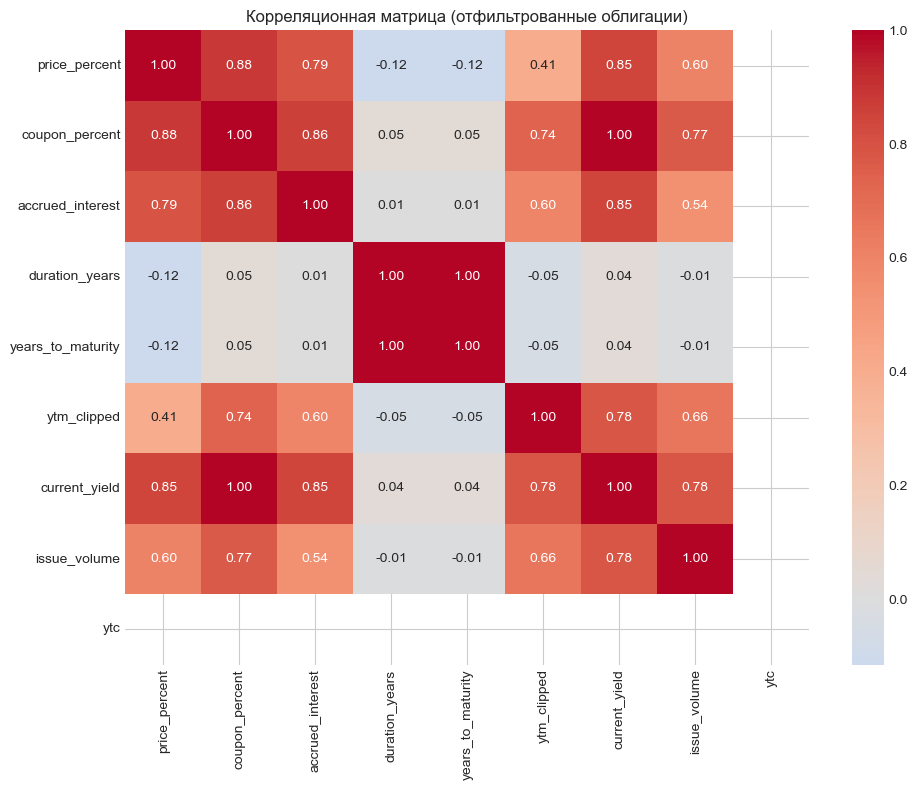

In [96]:
# 9. Визуализации (только для отфильтрованных инструментов)

if len(filtered) == 0:
    print("⚠️ Нет отфильтрованных облигаций, визуализация невозможна.")
else:
    # Для удобства можно сократить длинные названия
    filtered['short_name'] = filtered['Инструмент сокр.'].str.slice(0, 25)

    # 9.1 Гистограмма распределения YTM
    fig1 = px.histogram(filtered, x='ytm_clipped', nbins=50,
                        title='Распределение YTM (отфильтрованные облигации)',
                        labels={'ytm_clipped': 'YTM, %', 'count': 'Количество облигаций'})
    fig1.show()

    # 9.2 Диаграмма разброса YTM vs дюрация с подписями
    if 'issue_volume' in filtered.columns:
        filtered['log_volume'] = np.log10(filtered['issue_volume'] + 1)
        size_col = 'log_volume'
    else:
        size_col = None

    fig2 = px.scatter(filtered, x='duration_years', y='ytm_clipped', color='Rating',
                      size=size_col, hover_data=['Инструмент сокр.', 'coupon_percent', 'price_percent'],
                      text='short_name',   # подписи точек
                      title='YTM vs Дюрация (отфильтрованные облигации)',
                      labels={'duration_years': 'Дюрация, лет', 'ytm_clipped': 'YTM, %'})
    fig2.update_traces(textposition='top center', textfont=dict(size=8))
    fig2.show()

    # 9.3 Кривая доходности с подписями
    fig3 = px.scatter(filtered, x='years_to_maturity', y='ytm_clipped', color='Rating',
                      text='short_name',   # подписи точек
                      title='Кривая доходности (отфильтрованные облигации)',
                      labels={'years_to_maturity': 'Время до погашения, лет',
                              'ytm_clipped': 'YTM, %'})
    fig3.update_traces(textposition='top center', textfont=dict(size=8))
    fig3.show()

    # 9.4 Корреляционная матрица (для отфильтрованных)
    numeric_features = ['price_percent', 'coupon_percent', 'accrued_interest',
                        'duration_years', 'years_to_maturity', 'ytm_clipped', 'current_yield']
    if 'issue_volume' in filtered.columns:
        numeric_features.append('issue_volume')
    if 'ytc' in filtered.columns:
        numeric_features.append('ytc')
    numeric_features = [f for f in numeric_features if f in filtered.columns]

    if len(numeric_features) > 1:
        corr_matrix = filtered[numeric_features].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Корреляционная матрица (отфильтрованные облигации)')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Недостаточно данных для корреляционной матрицы.")

    # 9.5 Распределение объёмов выпуска по рейтингам (отфильтрованные)
    if 'issue_volume' in filtered.columns and 'Rating' in filtered.columns:
        volume_by_rating = filtered.groupby('Rating')['issue_volume'].sum().sort_values(ascending=False)
        fig6 = px.pie(values=volume_by_rating.values, names=volume_by_rating.index,
                      title='Распределение объёмов выпуска по рейтингам (отфильтрованные облигации)')
        fig6.show()
    else:
        print("⚠️ Нет данных об объёме выпуска или рейтингах, график пропущен.")